# Model 4 — Hospital Resource Forecasting

**Dataset:** `healthcare_admissions.csv` (55,500 admission records, 2019-05-08 to 2024-05-07 — 5 years of daily data)

**Forecast targets:**
1. **Patient Admissions** — count of new admissions per day (directly observed)
2. **Bed Occupancy** — count of patients occupying a bed on a given day, derived from each patient's admission→discharge interval (directly computed, not a proxy)
3. **ICU Demand** — ⚠️ **proxy**: the dataset has no ICU/ward field, so `Emergency`-type admissions per day are used as a stand-in for acute/ICU-level demand. Treat this series directionally, not as literal ICU census.

**Algorithms:** Prophet, ARIMA — one univariate model per algorithm per series (6 models total)
**Forecast horizon:** 90 days beyond the historical data, with the final 90 days of history held out to evaluate accuracy first.

*Author: Nusrat — Data Analyst @ Wmolex | Educator, Gurukul Institute of Advanced Technology*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

HORIZON = 90  # days to forecast forward, also the size of the holdout window for evaluation


Importing plotly failed. Interactive plots will not work.


## 1. Load Data

In [2]:
df = pd.read_csv('healthcare_admissions.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date of Admission'].min().date()} to {df['Date of Admission'].max().date()}")
df.head()


Shape: (55500, 15)
Date range: 2019-05-08 to 2024-05-07


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Build the Three Daily Time Series

- **Admissions**: `groupby` day, count of rows
- **Bed Occupancy**: for each admission, +1 on admission day and −1 the day after discharge; cumulative sum gives beds occupied on any given day
- **ICU Demand (proxy)**: daily count of `Admission Type == 'Emergency'` records


In [3]:
full_range = pd.date_range(df['Date of Admission'].min(), df['Date of Admission'].max(), freq='D')

# --- Patient Admissions ---
admissions_daily = df.groupby(df['Date of Admission'].dt.date).size()
admissions_daily.index = pd.to_datetime(admissions_daily.index)
admissions_daily = admissions_daily.reindex(full_range, fill_value=0)

# --- Bed Occupancy ---
occ = pd.Series(0, index=full_range)
admit_counts = df['Date of Admission'].dt.normalize().value_counts()
discharge_next_day = (df['Discharge Date'] + pd.Timedelta(days=1)).dt.normalize().value_counts()
occ = occ.add(admit_counts, fill_value=0).sub(discharge_next_day, fill_value=0)
occ = occ.reindex(full_range, fill_value=0).cumsum()

# --- ICU Demand (proxy: Emergency admissions per day) ---
icu_daily = df[df['Admission Type'] == 'Emergency'].groupby(
    df.loc[df['Admission Type'] == 'Emergency', 'Date of Admission'].dt.date
).size()
icu_daily.index = pd.to_datetime(icu_daily.index)
icu_daily = icu_daily.reindex(full_range, fill_value=0)

series = {
    'Patient Admissions': admissions_daily,
    'Bed Occupancy': occ,
    'ICU Demand (proxy)': icu_daily
}

for name, s in series.items():
    print(f"{name}: mean={s.mean():.1f}, std={s.std():.1f}, min={s.min()}, max={s.max()}")


Patient Admissions: mean=30.4, std=6.1, min=12, max=50
Bed Occupancy: mean=498.4, std=40.7, min=27.0, max=593.0
ICU Demand (proxy): mean=10.0, std=3.5, min=1, max=24


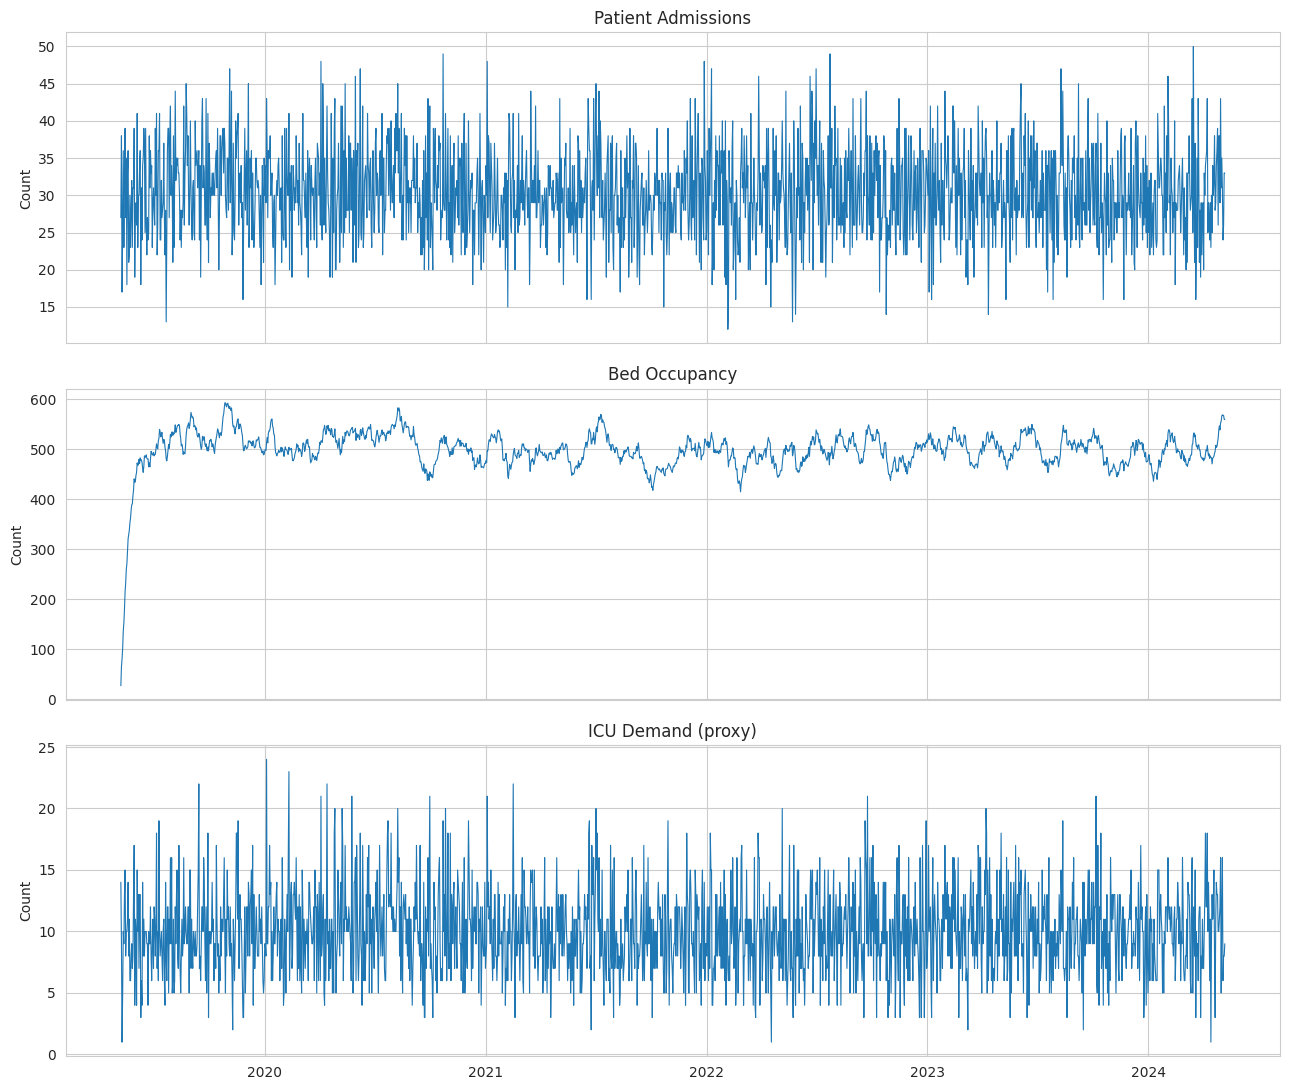

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (name, s) in zip(axes, series.items()):
    ax.plot(s.index, s.values, linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Train / Holdout Split

Last 90 days held out from each series to evaluate forecast accuracy before projecting forward.


In [5]:
def train_test_split_series(s, horizon=HORIZON):
    return s.iloc[:-horizon], s.iloc[-horizon:]

splits = {name: train_test_split_series(s) for name, s in series.items()}
for name, (train, test) in splits.items():
    print(f"{name}: train={len(train)} days, test={len(test)} days")


Patient Admissions: train=1737 days, test=90 days
Bed Occupancy: train=1737 days, test=90 days
ICU Demand (proxy): train=1737 days, test=90 days


## 4. Prophet Models

One Prophet model per series, with weekly + yearly seasonality (daily seasonality off — these are already daily aggregates).


In [6]:
def fit_prophet(train_series):
    df_p = train_series.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                interval_width=0.9)
    m.fit(df_p)
    return m

prophet_models = {}
prophet_forecasts = {}

for name, (train, test) in splits.items():
    m = fit_prophet(train)
    future = m.make_future_dataframe(periods=HORIZON)
    fc = m.predict(future)
    prophet_models[name] = m
    prophet_forecasts[name] = fc
    print(f"Prophet fit complete: {name}")


10:29:36 - cmdstanpy - INFO - Chain [1] start processing


10:29:36 - cmdstanpy - INFO - Chain [1] done processing


10:29:36 - cmdstanpy - INFO - Chain [1] start processing


Prophet fit complete: Patient Admissions


10:29:36 - cmdstanpy - INFO - Chain [1] done processing


10:29:37 - cmdstanpy - INFO - Chain [1] start processing


10:29:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit complete: Bed Occupancy


Prophet fit complete: ICU Demand (proxy)


## 5. ARIMA Models

One ARIMA(2,1,2) model per series — a reasonable general-purpose order for daily count data with mild trend/noise; weekly seasonality isn't modeled directly by plain ARIMA (SARIMA would be needed for that), so Prophet is expected to have an edge on the more seasonal series.


In [7]:
arima_models = {}
arima_forecasts = {}

for name, (train, test) in splits.items():
    model = ARIMA(train.values, order=(2, 1, 2))
    fitted = model.fit()
    fc = fitted.get_forecast(steps=HORIZON)
    arima_models[name] = fitted
    arima_forecasts[name] = fc
    print(f"ARIMA fit complete: {name}")


ARIMA fit complete: Patient Admissions


ARIMA fit complete: Bed Occupancy


ARIMA fit complete: ICU Demand (proxy)


## 6. Forecast Accuracy on Holdout (MAE, RMSE)


In [8]:
eval_rows = []

for name, (train, test) in splits.items():
    # Prophet: pull predictions for the holdout window
    fc_p = prophet_forecasts[name]
    prophet_holdout_pred = fc_p.set_index('ds').loc[test.index, 'yhat'].values
    prophet_mae = mean_absolute_error(test.values, prophet_holdout_pred)
    prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_holdout_pred))

    # ARIMA
    arima_holdout_pred = arima_forecasts[name].predicted_mean
    arima_mae = mean_absolute_error(test.values, arima_holdout_pred)
    arima_rmse = np.sqrt(mean_squared_error(test.values, arima_holdout_pred))

    eval_rows.append({'Series': name, 'Model': 'Prophet', 'MAE': prophet_mae, 'RMSE': prophet_rmse})
    eval_rows.append({'Series': name, 'Model': 'ARIMA', 'MAE': arima_mae, 'RMSE': arima_rmse})

eval_df = pd.DataFrame(eval_rows).set_index(['Series', 'Model'])
eval_df.round(2)


MAE   RMSE
Series             Model                
Patient Admissions Prophet   4.84   6.29
                   ARIMA     4.76   6.17
Bed Occupancy      Prophet  30.83  42.80
                   ARIMA    25.14  28.67
ICU Demand (proxy) Prophet   2.85   3.49
                   ARIMA     2.76   3.42

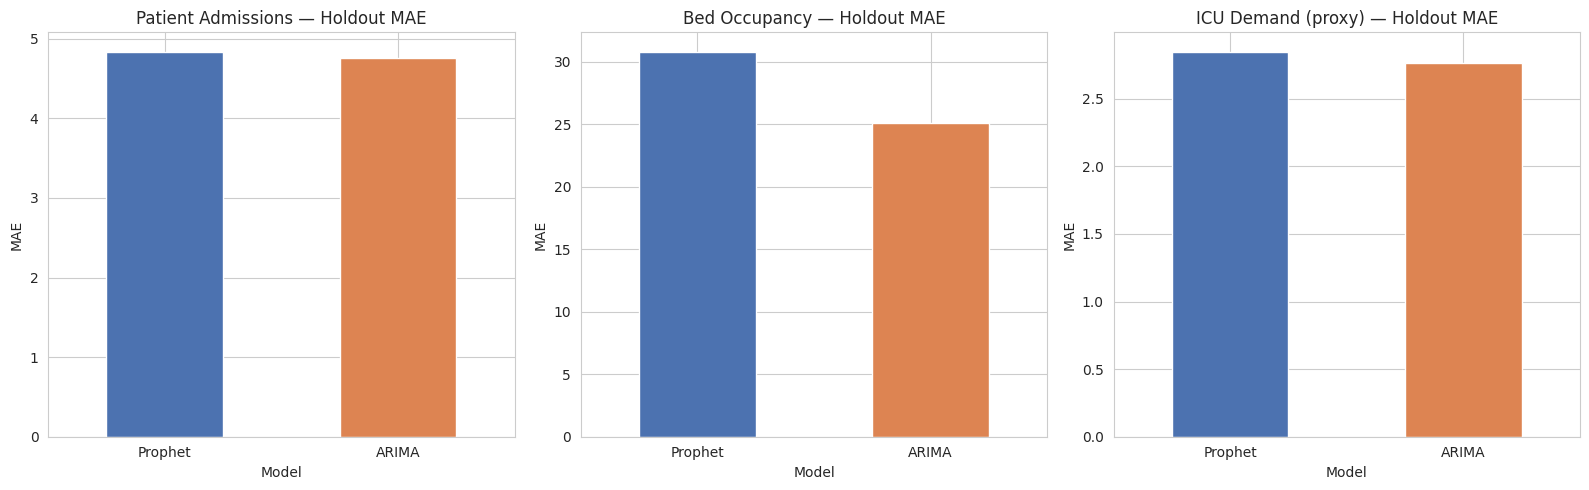

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, series.keys()):
    sub = eval_df.loc[name]
    sub['MAE'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{name} — Holdout MAE')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 7. Holdout Forecast vs Actual — Visual Check


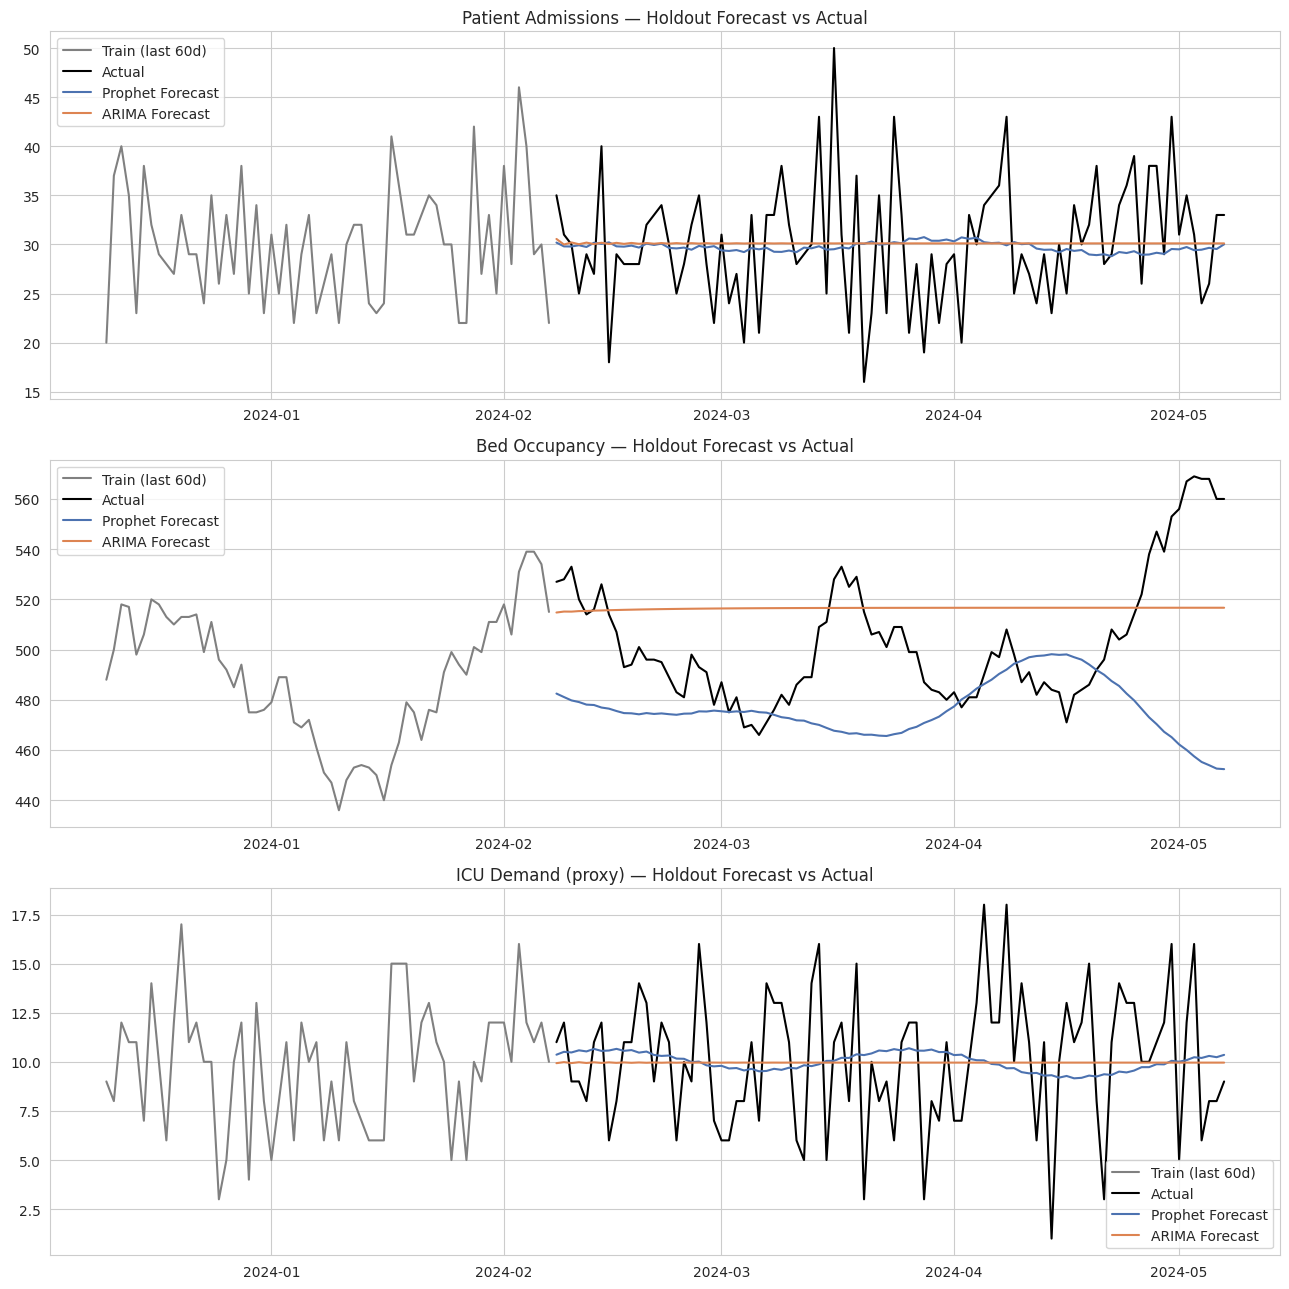

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13))
for ax, name in zip(axes, series.keys()):
    train, test = splits[name]
    ax.plot(train.index[-60:], train.values[-60:], label='Train (last 60d)', color='gray')
    ax.plot(test.index, test.values, label='Actual', color='black', linewidth=1.5)

    fc_p = prophet_forecasts[name].set_index('ds').loc[test.index, 'yhat']
    ax.plot(test.index, fc_p.values, label='Prophet Forecast', color='#4C72B0')

    arima_pred = arima_forecasts[name].predicted_mean
    ax.plot(test.index, arima_pred, label='ARIMA Forecast', color='#DD8452')

    ax.set_title(f'{name} — Holdout Forecast vs Actual')
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Forward Forecast — Next 90 Days (Refit on Full History)

Refitting both models on the **full** series (no holdout) to project 90 days beyond the last observed date, for actual planning use.


In [11]:
future_forecasts = {}

for name, s in series.items():
    # Prophet
    df_p = s.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, interval_width=0.9)
    m.fit(df_p)
    future = m.make_future_dataframe(periods=HORIZON)
    prophet_fc = m.predict(future)

    # ARIMA
    model = ARIMA(s.values, order=(2, 1, 2))
    fitted = model.fit()
    arima_fc = fitted.get_forecast(steps=HORIZON)
    arima_index = pd.date_range(s.index[-1] + pd.Timedelta(days=1), periods=HORIZON)

    future_forecasts[name] = {
        'prophet': prophet_fc,
        'arima_mean': arima_fc.predicted_mean,
        'arima_ci': arima_fc.conf_int(alpha=0.1),
        'arima_index': arima_index
    }
    print(f"Forward forecast complete: {name}")


10:29:38 - cmdstanpy - INFO - Chain [1] start processing


10:29:39 - cmdstanpy - INFO - Chain [1] done processing


10:29:39 - cmdstanpy - INFO - Chain [1] start processing


Forward forecast complete: Patient Admissions


10:29:39 - cmdstanpy - INFO - Chain [1] done processing


10:29:40 - cmdstanpy - INFO - Chain [1] start processing


10:29:40 - cmdstanpy - INFO - Chain [1] done processing


Forward forecast complete: Bed Occupancy


Forward forecast complete: ICU Demand (proxy)


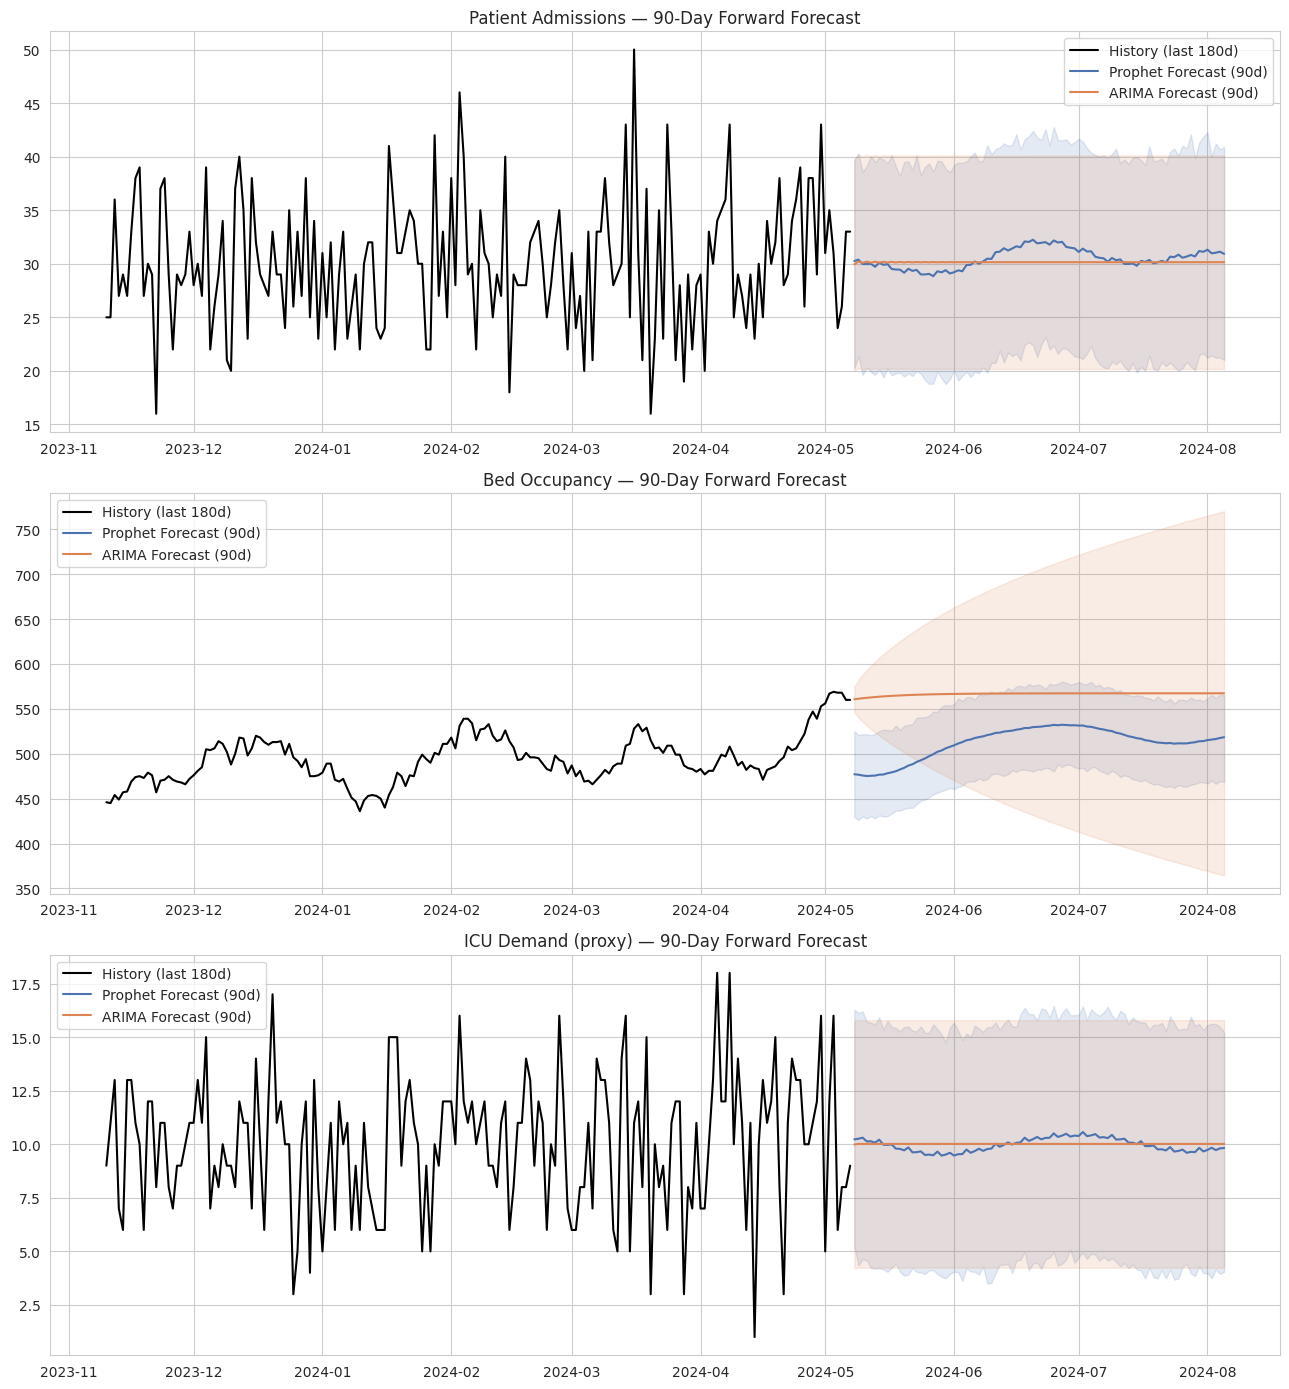

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 14))
for ax, name in zip(axes, series.keys()):
    s = series[name]
    ax.plot(s.index[-180:], s.values[-180:], label='History (last 180d)', color='black')

    fc = future_forecasts[name]
    prophet_future = fc['prophet'][fc['prophet']['ds'] > s.index[-1]]
    ax.plot(prophet_future['ds'], prophet_future['yhat'], label='Prophet Forecast (90d)', color='#4C72B0')
    ax.fill_between(prophet_future['ds'], prophet_future['yhat_lower'], prophet_future['yhat_upper'],
                     color='#4C72B0', alpha=0.15)

    ax.plot(fc['arima_index'], fc['arima_mean'], label='ARIMA Forecast (90d)', color='#DD8452')
    ax.fill_between(fc['arima_index'], fc['arima_ci'][:, 0], fc['arima_ci'][:, 1],
                     color='#DD8452', alpha=0.15)

    ax.set_title(f'{name} — 90-Day Forward Forecast')
    ax.legend()
plt.tight_layout()
plt.show()


## 9. Prophet Component Decomposition — Patient Admissions

Trend and weekly/yearly seasonality breakdown for the admissions series, useful for understanding *why* the forecast looks the way it does (e.g., weekday vs weekend admission patterns).


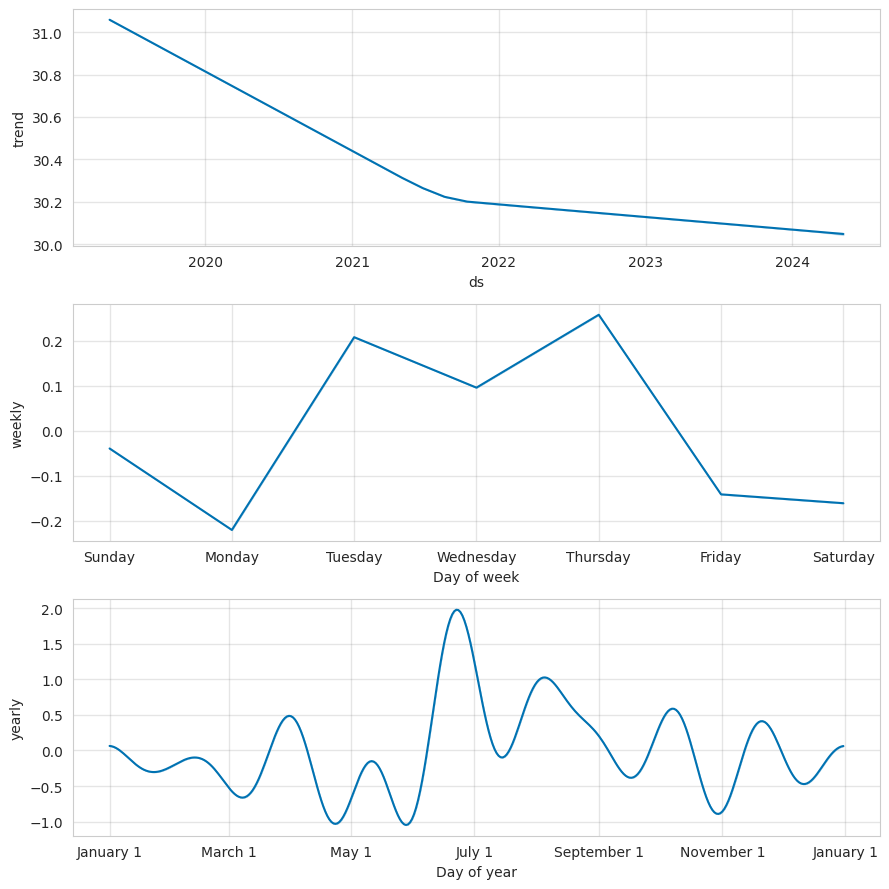

In [13]:
m_admissions = prophet_models['Patient Admissions']
fc_admissions = prophet_forecasts['Patient Admissions']
fig = m_admissions.plot_components(fc_admissions)
plt.tight_layout()
plt.show()


## 10. Summary

- Three daily series were forecast with both Prophet and ARIMA: **Patient Admissions** and **Bed Occupancy** are directly computed from real admission/discharge dates; **ICU Demand** is a proxy (Emergency-type admissions) since no ICU field exists in the source data — flag this if the forecast feeds a real capacity-planning decision.
- Holdout evaluation (last 90 days) shows which algorithm performs better per series in the MAE/RMSE table above — Prophet is generally expected to have an edge wherever weekly/yearly seasonality is meaningful, since plain ARIMA(2,1,2) here doesn't model seasonality directly.
- Section 8 gives the actual forward-looking 90-day forecast (refit on full history) for planning purposes, with 90% confidence intervals shown for both models.
- **Caveat:** these are univariate time-series models — they don't account for external factors (flu season, local outbreaks, hospital policy changes, capacity constraints) that would materially affect real-world admissions/occupancy. Treat forecasts as a baseline, not a substitute for domain judgment.
